In [ ]:
!pip install torch==2.5.1 --index-url https://download.pytorch.org/whl/cu121

import torch
v = "2.5.0"

!pip install torch-scatter torch-sparse pyg-lib -f https://data.pyg.org/whl/torch-{v}+cu121.html
!pip install torch-geometric

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html


In [ ]:
import ast
import json
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize
import kagglehub

import torch
import torch.nn.functional as F
from torch import Tensor
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.metrics import LinkPredRecall, LinkPredNDCG, LinkPredMRR
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.utils import coalesce

import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:

DATA_PATH = kagglehub.dataset_download(
    "pypiahmad/steam-video-game-and-bundle-data",
    path="australian_users_items.json"
)

Using Colab cache for faster access to the 'steam-video-game-and-bundle-data' dataset.


In [ ]:
K_VAL = 20
RANDOM_SEED = 42

def create_pyg_graph(file_path):
    data = HeteroData()

    user_map = {}
    item_map = {}

    item_names = []

    sources = []
    targets = []

    with open(file_path, encoding='utf-8') as f:
      for line in f:
          user = ast.literal_eval(line)
          u_id = str(user['user_id'])

          if u_id not in user_map:
              user_map[u_id] = len(user_map)
          u_idx = user_map[u_id]

          for item in user['items']:
              i_id = str(item.get('item_id'))

              if i_id not in item_map:
                  item_map[i_id] = len(item_map)
                  item_names.append(item.get('item_name', 'Unknown'))

              i_idx = item_map[i_id]

              sources.append(u_idx)
              targets.append(i_idx)

    num_users = len(user_map)
    num_items = len(item_map)

    data['user'].num_nodes = num_users
    data['item'].num_nodes = num_items

    data['user'].node_id = torch.arange(num_users)
    data['item'].node_id = torch.arange(num_items)

    edge_index = torch.tensor([sources, targets], dtype=torch.long)
    edge_index = coalesce(edge_index)
    data['user', 'purchased', 'item'].edge_index = edge_index

    data = T.ToUndirected()(data)

    print(f" users: {num_users}")
    print(f" items: {num_items}")
    return data, item_names, user_map, item_map, num_users, num_items


data, item_names, user_map, item_map, num_items, num_users = create_pyg_graph(DATA_PATH)


 users: 87626
 items: 10978


In [ ]:

transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    disjoint_train_ratio=0.3,
    neg_sampling_ratio=2.0,
    add_negative_train_samples=False,
    edge_types=("user", "purchased", "item"),
    rev_edge_types=("item", "rev_purchased", "user"),
)
train_data, val_data, test_data = transform(data)

train_sup_index  = train_data["user", "purchased", "item"].edge_label_index
train_sup_labels = train_data["user", "purchased", "item"].edge_label
train_pos_edges  = train_sup_index[:, train_sup_labels == 1]


In [ ]:
def run_evaluation(val_split, train_sparse_matrix, score_matrix, k=20):

    edge_index = val_split["user", "purchased", "item"].edge_label_index
    edge_label = val_split["user", "purchased", "item"].edge_label
    pos_mask = (edge_label == 1)

    scores = torch.from_numpy(score_matrix).float()
    train_mask = torch.from_numpy(train_sparse_matrix.toarray()).bool()
    scores[train_mask] = -float('inf')          # mask known training interactions
    _, topk_indices = torch.topk(scores, k=k, dim=1)

    recall_metric = LinkPredRecall(k=k)
    ndcg_metric   = LinkPredNDCG(k=k)
    mrr_metric    = LinkPredMRR(k=k)

    pos_edge_index = edge_index[:, pos_mask]
    recall_metric.update(pred_index_mat=topk_indices, edge_label_index=pos_edge_index)
    ndcg_metric.update(pred_index_mat=topk_indices,   edge_label_index=pos_edge_index)
    mrr_metric.update(pred_index_mat=topk_indices,    edge_label_index=pos_edge_index)

    val_users = edge_index[0].numpy()
    val_items = edge_index[1].numpy()

    raw_scores = torch.from_numpy(score_matrix).float()
    val_predictions = raw_scores[val_users, val_items].numpy()
    y_true = edge_label.numpy()
    val_auc = roc_auc_score(y_true, val_predictions)

    return (
        recall_metric.compute().item(),
        ndcg_metric.compute().item(),
        mrr_metric.compute().item(),
        val_auc
    )


In [ ]:
class ClassicalGraphPredictor:

    def __init__(self, num_users, num_items, method='resource_allocation'):
        self.num_users = num_users
        self.num_items = num_items
        self.method = method
        self.R_train = None
        self.user_degrees = None
        self.item_degrees = None
        self.projection_matrix = None

    def fit(self, edge_index):
        self.R_train = sp.csr_matrix(
            (np.ones(edge_index.shape[1]),
             (edge_index[0].numpy(), edge_index[1].numpy())),
            shape=(self.num_users, self.num_items)
        )
        self.user_degrees = np.array(self.R_train.sum(axis=1)).flatten()
        self.item_degrees = np.array(self.R_train.sum(axis=0)).flatten()

        if self.method == 'preferential_attachment':
            return
        elif self.method == 'jaccard':
            self.projection_matrix = (self.R_train.T @ self.R_train).tocsr()
        elif self.method == 'resource_allocation':
            W_user = normalize(self.R_train, norm='l1', axis=1)
            self.projection_matrix = (self.R_train.T @ W_user).tocsr()
        elif self.method == 'heat_conduction':
            W_user = normalize(self.R_train, norm='l1', axis=1)
            W_item = normalize(self.R_train, norm='l1', axis=0)
            self.projection_matrix = (W_item.T @ W_user).tocsr()

    def predict_all(self):
        if self.method == 'preferential_attachment':
            return self.user_degrees[:, None] * self.item_degrees[None, :]
        return (self.R_train @ self.projection_matrix).toarray()


In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x


class Classifier(torch.nn.Module):
    def forward(self, x_user: Tensor, x_item: Tensor, edge_label_index: Tensor) -> Tensor:
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_item = x_item[edge_label_index[1]]
        return (edge_feat_user * edge_feat_item).sum(dim=-1)


class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.item_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.item_emb = torch.nn.Embedding(data["item"].num_nodes, hidden_channels)
        self.gnn = to_hetero(GNN(hidden_channels), metadata=data.metadata())
        self.classifier = Classifier()

    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
            "user": self.user_emb(data["user"].node_id),
            "item": self.item_emb(data["item"].node_id)
        }
        x_dict = self.gnn(x_dict, data.edge_index_dict)
        return self.classifier(
            x_dict["user"],
            x_dict["item"],
            data["user", "purchased", "item"].edge_label_index
        )

    @torch.no_grad()
    def get_score_matrix(self, train_data):
        self.eval()
        edge_index_dict = {k: v.to(device) for k, v in train_data.edge_index_dict.items()}
        x_dict = {
            "user": self.user_emb(data["user"].node_id.to(device)),
            "item": self.item_emb(data["item"].node_id.to(device))
        }
        x_dict = self.gnn(x_dict, edge_index_dict)
        scores = torch.matmul(x_dict["user"], x_dict["item"].t())
        return scores.cpu().numpy()


In [ ]:
HIDDEN_CHANNELS = 64
EPOCHS = 5
LR = 0.001
BATCH_SIZE = 8192

gnn_model = Model(hidden_channels=HIDDEN_CHANNELS).to(device)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=LR)


train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,
    edge_label_index=(("user", "purchased", "item"), train_data["user", "purchased", "item"].edge_label_index),
    edge_label=train_data["user", "purchased", "item"].edge_label,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)


for epoch in range(1, EPOCHS + 1):
    total_loss = total_examples = 0
    gnn_model.train()
    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        sampled_data.to(device)
        pred = gnn_model(sampled_data)

        ground_truth = sampled_data["user", "purchased", "item"].edge_label
        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * pred.numel()
        total_examples += pred.numel()
    print(f"Epoch: {epoch:03d}, Loss: {total_loss / total_examples:.4f}")


100%|██████████| 150/150 [00:04<00:00, 32.29it/s]


Epoch: 001, Loss: 0.3679


100%|██████████| 150/150 [00:03<00:00, 40.52it/s]


Epoch: 002, Loss: 0.2312


100%|██████████| 150/150 [00:03<00:00, 38.11it/s]


Epoch: 003, Loss: 0.2150


100%|██████████| 150/150 [00:03<00:00, 39.64it/s]


Epoch: 004, Loss: 0.2075


100%|██████████| 150/150 [00:03<00:00, 41.07it/s]

Epoch: 005, Loss: 0.2020


In [18]:
results = []
classical_methods = [
    'preferential_attachment',
    'jaccard',
    'resource_allocation',
    'heat_conduction'
]

score_matrices = []

for method in classical_methods:
    model = ClassicalGraphPredictor(num_users, num_items, method=method)
    model.fit(train_pos_edges)
    score_matrix = model.predict_all()
    score_matrices.append((method,score_matrix))

    rec, ndcg, mrr, auc = run_evaluation(val_data, model.R_train, score_matrix, k=K_VAL)
    results.append({
        'name': method,
        'recall': rec, 'ndcg': ndcg, 'mrr': mrr, 'auc': auc
    })
    print(method)

gnn_scores = gnn_model.get_score_matrix(train_data)
score_matrices.append(('gnn', gnn_scores))

mp_edge_index = train_data["user", "purchased", "item"].edge_index
gnn_train_sparse = sp.csr_matrix(
    (np.ones(mp_edge_index.shape[1]),
     (mp_edge_index[0].numpy(), mp_edge_index[1].numpy())),
    shape=(num_users, num_items)
)

rec, ndcg, mrr, auc = run_evaluation(val_data, gnn_train_sparse, gnn_scores, k=K_VAL)
results.append({
    'name': 'gnn',
    'recall': rec, 'ndcg': ndcg, 'mrr': mrr, 'auc': auc
})
print(f"  gnn done.")

print()
header = f"{'Model':<25} | {f'Recall@{K_VAL}':<10} | {f'NDCG@{K_VAL}':<10} | {f'MRR@{K_VAL}':<10} | {'AUC':<10}"
print(header)
print('=' * len(header))
for r in results:
    print(f"{r['name']:<25} | {r['recall']:<10.4f} | {r['ndcg']:<10.4f} | {r['mrr']:<10.4f} | {r['auc']:<10.4f}")
print('=' * len(header))

preferential_attachment
jaccard
resource_allocation
heat_conduction
  gnn done.

Model                     | Recall@20  | NDCG@20    | MRR@20     | AUC       
preferential_attachment   | 0.1921     | 0.1330     | 0.2064     | 0.9713    
jaccard                   | 0.2181     | 0.1488     | 0.2227     | 0.9711    
resource_allocation       | 0.2240     | 0.1517     | 0.2239     | 0.9684    
heat_conduction           | 0.2334     | 0.1557     | 0.2257     | 0.9785    
gnn                       | 0.2235     | 0.1630     | 0.2579     | 0.9763    


In [ ]:
@torch.no_grad()
def recommend_for_user(user_id_str, model, train_data, k=10):
    if user_id_str not in user_map:
        print(f"User '{user_id_str}' not found.")
        return

    u_idx = user_map[user_id_str]
    edge_index = data['user', 'purchased', 'item'].edge_index
    owned_indices = edge_index[1, edge_index[0] == u_idx].tolist()
    owned_games = [item_names[i] for i in owned_indices]

    score_matrix = gnn_model.get_score_matrix(train_data)
    user_scores = score_matrix[u_idx].copy()

    for i in owned_indices:
        user_scores[i] = -np.inf

    top_indices = np.argsort(-user_scores)[:k]
    recommendations = [item_names[i] for i in top_indices]

    print(f"=== User: {user_id_str} ===")
    print(f"Library ({len(owned_games)} games):")
    for g in owned_games[:30]:
        print(f"  - {g}")
    if len(owned_games) > 30:
        print(f"  ... and {len(owned_games) - 30} more.")
    print(f"\nTop {k} Recommendations:")
    for i, g in enumerate(recommendations, 1):
        print(f"  {i:2d}. {g}")
    print('=' * 40)


demo_user = list(user_map.keys())[30]
recommend_for_user(demo_user, gnn_model, train_data, k=10)

=== User: fdcfelipefdc ===
Library (43 games):
  - Borderlands
  - Dota 2 Test
  - Counter-Strike: Global Offensive
  - War Thunder
  - PAYDAY 2
  - Insurgency
  - Dead Island: Epidemic
  - Evolve Stage 2
  - Garry's Mod
  - Age of Empires® III: Complete Collection
  - Castle Crashers
  - Quake Live
  - Magicka: Wizard Wars
  - Sniper Elite V2
  - PAYDAY: The Heist
  - Transformice
  - ARK: Survival Evolved
  - ARK: Survival Of The Fittest
  - Immune
  - Warframe
  - Path of Exile
  - No More Room in Hell
  - Rocket League
  - Bloody Trapland
  - Unturned
  - RaceRoom Racing Experience 
  - Aura Kingdom
  - Robocraft
  - TERA
  - Grand Theft Auto V
  ... and 13 more.

Top 10 Recommendations:
   1. Left 4 Dead 2
   2. Left 4 Dead 2 Beta
   3. Terraria
   4. Portal 2
   5. Heroes & Generals
   6. PlanetSide 2
   7. Warface
   8. Dirty Bomb
   9. Loadout
  10. Portal


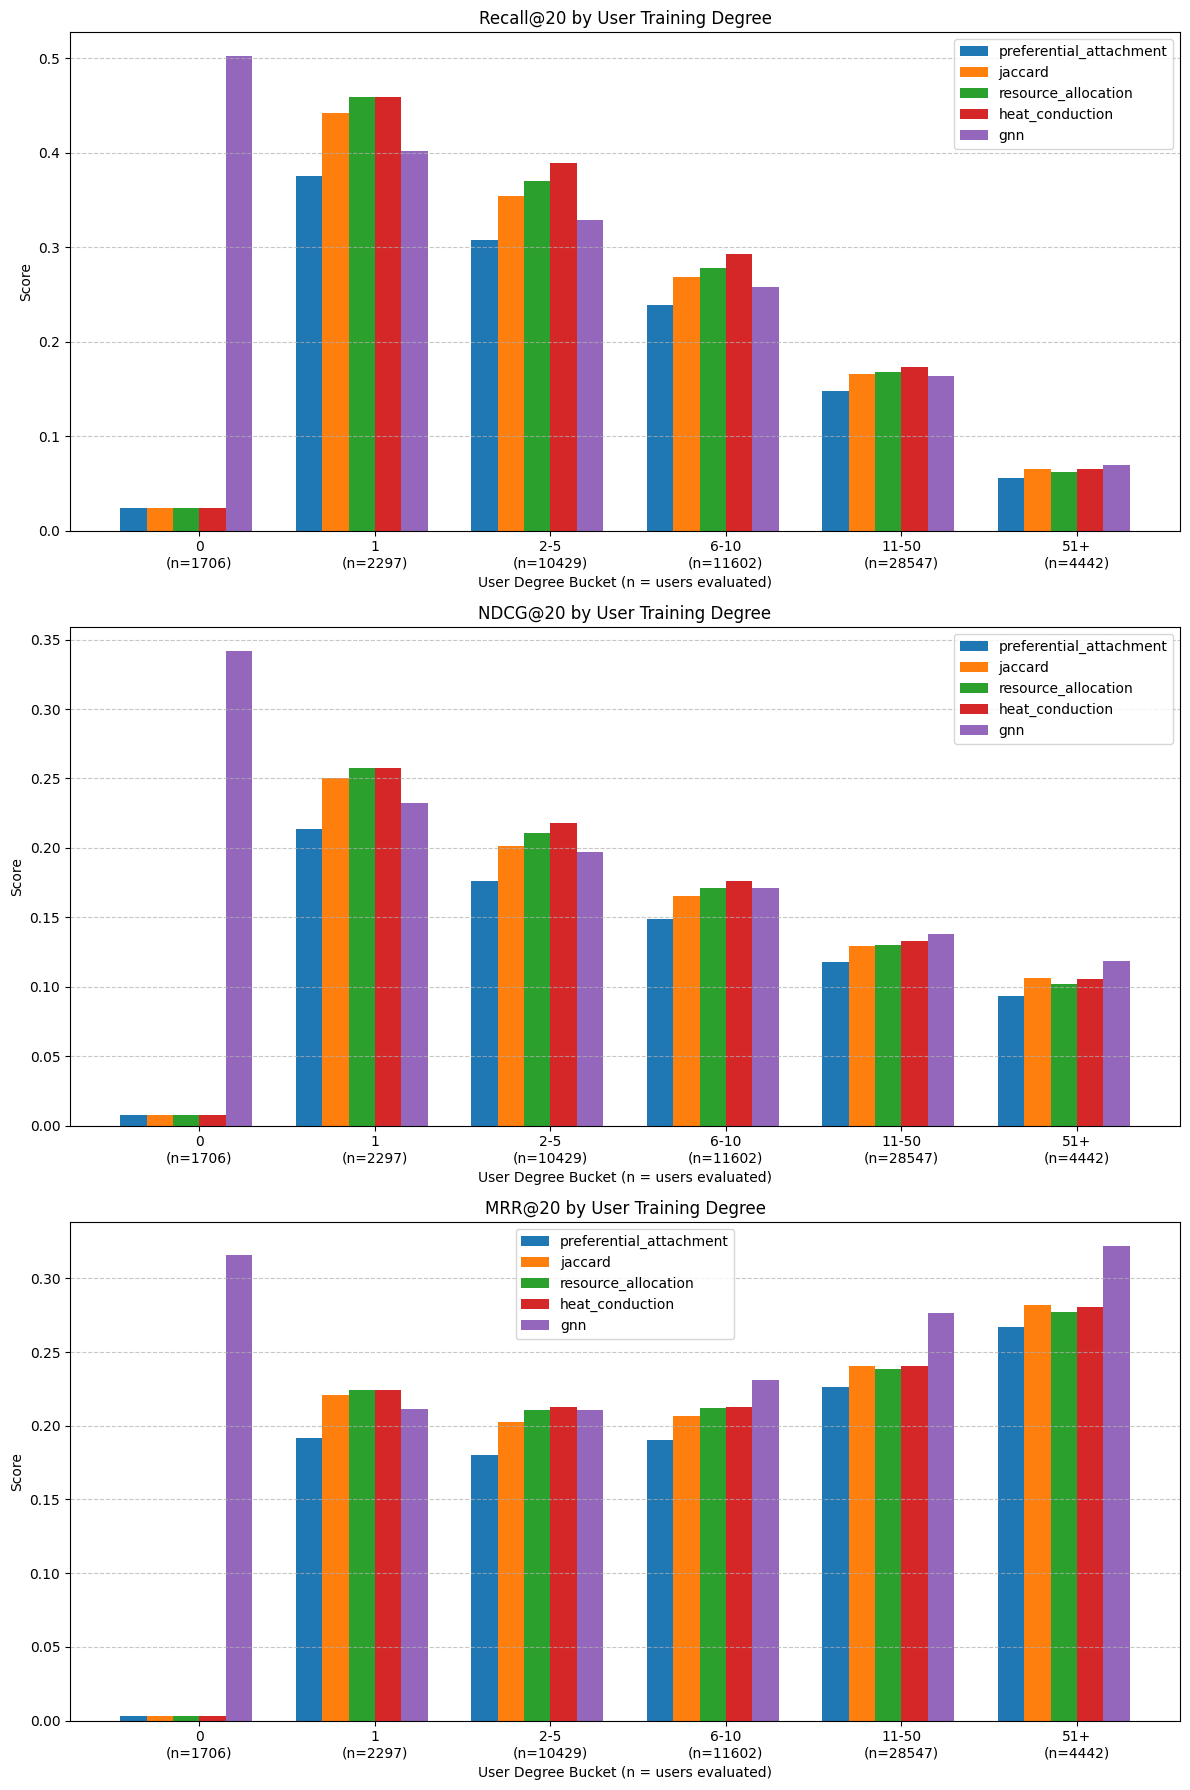

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

def get_bucketed_metrics(val_data, train_sparse, score_matrix, user_degrees, k=20):
    buckets = [(-1, 0), (0, 1), (1, 5), (5, 10), (10, 50), (50, float('inf'))]

    edge_index = val_data["user", "purchased", "item"].edge_label_index
    edge_label = val_data["user", "purchased", "item"].edge_label
    pos_mask = (edge_label == 1)
    pos_edge_index = edge_index[:, pos_mask]

    scores_t = torch.from_numpy(score_matrix).float()
    train_mask = torch.from_numpy(train_sparse.toarray()).bool()
    scores_t[train_mask] = -float('inf')
    _, topk_indices = torch.topk(scores_t, k=k, dim=1)

    bucket_results = []
    bucket_counts = []

    for i, (low, high) in enumerate(buckets):
        idx = np.where((user_degrees > low) & (user_degrees <= high))[0]
        user_mask = np.isin(pos_edge_index[0].numpy(), idx)
        num_users_in_eval = len(np.unique(pos_edge_index[0][user_mask].numpy()))
        bucket_counts.append(num_users_in_eval)

        if not np.any(user_mask):
            bucket_results.append([0.0, 0.0, 0.0])
            continue

        b_pos_edges = pos_edge_index[:, user_mask]
        rec_m, ndcg_m, mrr_m = LinkPredRecall(k=k), LinkPredNDCG(k=k), LinkPredMRR(k=k)
        rec_m.update(pred_index_mat=topk_indices, edge_label_index=b_pos_edges)
        ndcg_m.update(pred_index_mat=topk_indices, edge_label_index=b_pos_edges)
        mrr_m.update(pred_index_mat=topk_indices, edge_label_index=b_pos_edges)

        bucket_results.append([rec_m.compute().item(), ndcg_m.compute().item(), mrr_m.compute().item()])

    return np.array(bucket_results), bucket_counts

train_user_degrees = np.array(sp.csr_matrix((np.ones(train_pos_edges.shape[1]), (train_pos_edges[0].numpy(), train_pos_edges[1].numpy())), shape=(num_users, num_items)).sum(axis=1)).flatten()
all_plot_data = {}
final_counts = None

for name, s_mat in score_matrices:
    tsm = gnn_train_sparse if name == 'gnn' else sp.csr_matrix((np.ones(train_pos_edges.shape[1]), (train_pos_edges[0].numpy(), train_pos_edges[1].numpy())), shape=(num_users, num_items))
    res, counts = get_bucketed_metrics(val_data, tsm, s_mat, train_user_degrees, k=K_VAL)
    all_plot_data[name] = res
    final_counts = counts

metrics = ['Recall', 'NDCG', 'MRR']
base_labels = ['0', '1', '2-5', '6-10', '11-50', '51+']
bucket_labels_with_counts = [f"{lbl}\n(n={cnt})" for lbl, cnt in zip(base_labels, final_counts)]
methods = [m[0] for m in score_matrices]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
x = np.arange(len(bucket_labels_with_counts))
width = 0.15

for m_idx, metric_name in enumerate(metrics):
    ax = axes[m_idx]
    for i, method in enumerate(methods):
        ax.bar(x + i*width - (len(methods)*width)/2, all_plot_data[method][:, m_idx], width, label=method)
    ax.set_title(f'{metric_name}@{K_VAL} by User Training Degree')
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels_with_counts)
    ax.set_xlabel('User Degree Bucket (n = users evaluated)')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()